<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/kaggle_anticipative_casia_b_simcc_pure_dgnn_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/kaggle_anticipative_casia_b_simcc_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import classification_report, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')
print("✅ Libraries importées")
print(f"   PyTorch : {torch.__version__}")
print(f"   Device  : {DEVICE}")

✅ Libraries importées
   PyTorch : 2.10.0+cu128
   Device  : cuda


In [ ]:
# ============================================================
# CELL 2 — Download CASIA-B SimCC
# ============================================================
!pip install kagglehub --quiet
import kagglehub
path = kagglehub.dataset_download(
    "mireillejabbour/casia-b-simcc")
print(f"✅ CASIA-B SimCC path: {path}")

100%|██████████| 230M/230M [00:01<00:00, 152MB/s]

Extracting files...


✅ CASIA-B SimCC path: /root/.cache/kagglehub/datasets/mireillejabbour/casia-b-simcc/versions/1


In [ ]:
# ============================================================
# CELL 3 — Load CASIA-B_SimCC
# ============================================================
from pathlib import Path
from collections import Counter

DATA_ROOT = Path(path)   # 'path' comes from CELL 0
print(f"Dataset root: {DATA_ROOT}\n")

# --- Show folder structure (first 4 levels) ---
print("=== FOLDER STRUCTURE ===")
for root, dirs, files_ in os.walk(DATA_ROOT):
    level = str(root).replace(str(DATA_ROOT), '').count(os.sep)
    if level > 4:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files_)[:5]:
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f"{indent}  📄 {f}  ({size:.1f} KB)")

# --- Count file types ---
all_files = [f for f in DATA_ROOT.rglob('*') if f.is_file()]
exts = Counter(f.suffix.lower() for f in all_files)
print(f"\n=== FILE TYPES ===")
print(f"Total files : {len(all_files)}")
for ext, count in exts.most_common():
    print(f"  {ext if ext else 'no_ext'} : {count} files")

# --- Peek inside first 2 files ---
print("\n=== PEEK INSIDE FIRST 2 FILES ===")
for fp in all_files[:2]:
    ext = fp.suffix.lower()
    size = fp.stat().st_size / 1024
    print(f"\n📄 {fp.name}  ({size:.1f} KB)")
    print(f"   Full path: {fp}")
    try:
        if ext == '.pkl':
            with open(fp, 'rb') as f:
                d = pickle.load(f)
            if isinstance(d, np.ndarray):
                print(f"   → ndarray  shape={d.shape}  dtype={d.dtype}")
                print(f"   → min={d.min():.3f}  max={d.max():.3f}")
            elif isinstance(d, dict):
                print(f"   → dict  keys={list(d.keys())[:8]}")
                for k in list(d.keys())[:2]:
                    v = d[k]
                    print(f"      '{k}': type={type(v).__name__}  "
                          f"shape={np.array(v).shape if hasattr(v,'__len__') else v}")
            elif isinstance(d, list):
                print(f"   → list  len={len(d)}  "
                      f"elem_type={type(d[0]).__name__}")
                if hasattr(d[0], 'shape'):
                    print(f"   → elem_shape={d[0].shape}")
                elif hasattr(d[0], '__len__'):
                    print(f"   → elem_shape={np.array(d[0]).shape}")

        elif ext == '.npy':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npy  shape={d.shape}  dtype={d.dtype}")

        elif ext == '.npz':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npz  keys={list(d.keys())}")
            for k in list(d.keys())[:3]:
                print(f"      '{k}': shape={d[k].shape}")

        elif ext == '.csv':
            df = pd.read_csv(fp, nrows=3)
            print(f"   → csv  shape={df.shape}")
            print(f"   → cols={list(df.columns[:8])}")
            print(df.head(2).to_string())

    except Exception as e:
        print(f"   ❌ Error: {e}")

Streaming output truncated to the last 5000 lines.
        036/
          📄 093-cl-01-036-mapping.txt  (2.1 KB)
          📄 093-cl-01-036.pkl  (23.9 KB)
        126/
          📄 093-cl-01-126-mapping.txt  (1.8 KB)
          📄 093-cl-01-126.pkl  (20.5 KB)
      nm-02/
        108/
          📄 093-nm-02-108-mapping.txt  (1.8 KB)
          📄 093-nm-02-108.pkl  (21.1 KB)
        090/
          📄 093-nm-02-090-mapping.txt  (1.6 KB)
          📄 093-nm-02-090.pkl  (18.5 KB)
        072/
          📄 093-nm-02-072-mapping.txt  (1.8 KB)
          📄 093-nm-02-072.pkl  (20.7 KB)
        180/
          📄 093-nm-02-180-mapping.txt  (2.2 KB)
          📄 093-nm-02-180.pkl  (24.7 KB)
        144/
          📄 093-nm-02-144-mapping.txt  (2.0 KB)
          📄 093-nm-02-144.pkl  (23.1 KB)
        000/
          📄 093-nm-02-000-mapping.txt  (2.1 KB)
          📄 093-nm-02-000.pkl  (23.9 KB)
        054/
          📄 093-nm-02-054-mapping.txt  (1.9 KB)
          📄 093-nm-02-054.pkl  (21.3 KB)
        018/
     

In [ ]:
# ============================================================
# CELL 3B — Load CASIA-B SimCC into sequences
# ============================================================
import pickle, numpy as np
from tqdm import tqdm

def load_casia_b(root_path, conditions=None):
    root      = Path(root_path) / "CASIA-B_SimCC"
    pkl_files = sorted(root.rglob("*.pkl"))
    sequences = []
    metadata  = []
    skipped   = 0

    for fp in tqdm(pkl_files, desc="Loading CASIA-B SimCC"):
        parts = fp.relative_to(root).parts
        if len(parts) < 4:
            skipped += 1
            continue

        subject   = parts[0]                  # e.g. "057"
        cond_seq  = parts[1]                  # e.g. "cl-02"
        view      = parts[2]                  # e.g. "018"
        condition = cond_seq.split('-')[0]    # "cl"
        sequence  = cond_seq.split('-')[1]    # "02"

        if conditions and condition not in conditions:
            continue

        try:
            with open(fp, 'rb') as f:
                data = pickle.load(f)
            if not isinstance(data, np.ndarray):
                data = np.array(data, dtype=np.float32)
            if data.ndim != 3 or data.shape[1] != 17:
                skipped += 1
                continue
            if len(data) < 25:
                skipped += 1
                continue
            sequences.append(data.astype(np.float32))
            metadata.append({
                'subject'  : subject,
                'condition': condition,
                'sequence' : sequence,
                'view'     : view,
                'frames'   : len(data)
            })
        except Exception:
            skipped += 1

    print(f"\n✅ Chargées : {len(sequences)} séquences")
    print(f"   Ignorées : {skipped}")
    print(f"   Shape ex.: {sequences[0].shape}")
    conds = Counter(m['condition'] for m in metadata)
    print(f"   Conditions: {dict(conds)}")
    return sequences, metadata

sequences, metadata = load_casia_b(path, conditions=['nm'])

Loading CASIA-B SimCC: 100%|██████████| 13640/13640 [00:01<00:00, 8912.02it/s]


✅ Chargées : 8175 séquences
   Ignorées : 9
   Shape ex.: (96, 17, 3)
   Conditions: {'nm': 8175}


In [ ]:
# ============================================================
# CELL 4 — Feature Extraction + Build Windows (CASIA-B)
# ============================================================
WINDOW_SIZE   = 30
PREDICT_STEPS = 8
STRIDE        = 5
FPS           = 16

def extract_features(kp_seq):
    """(T,17,3) → (T,34) normalisé hip-centered
    SimCC channel 2 = confidence score → on garde uniquement x,y
    """
    xy         = kp_seq[:, :, :2].copy().astype(np.float32)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center, axis=1)
    torso_h    = np.maximum(torso_h, 1e-6)
    rel        = rel / torso_h[:, np.newaxis, np.newaxis]
    return rel.reshape(len(kp_seq), -1)   # (T, 34)

def build_windows(sequences, window_size=WINDOW_SIZE,
                  predict_steps=PREDICT_STEPS,
                  stride=STRIDE):
    X_list, Y_list = [], []
    for seq in tqdm(sequences, desc="Building windows"):
        feats   = extract_features(seq)
        T       = len(feats)
        min_len = window_size + predict_steps
        if T < min_len:
            continue
        for start in range(0, T - min_len + 1, stride):
            end_x = start + window_size
            end_y = end_x  + predict_steps
            X_list.append(feats[start:end_x])
            Y_list.append(feats[end_x:end_y])

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    print(f"\n✅ Windows : X={X.shape} | Y={Y.shape}")
    return X, Y

X, Y = build_windows(sequences)

Building windows: 100%|██████████| 8175/8175 [00:00<00:00, 11867.78it/s]



✅ Windows : X=(107489, 30, 34) | Y=(107489, 8, 34)


In [ ]:
# ============================================================
# CELL 5 — Architecture LSTMAnticipator
# ============================================================
import torch
import torch.nn as nn

class LSTMAnticipator(nn.Module):
    def __init__(self,
                 input_size    = 34,
                 hidden_size   = 256,
                 num_layers    = 2,
                 predict_steps = PREDICT_STEPS,
                 dropout       = 0.3):
        super().__init__()
        self.predict_steps = predict_steps
        self.hidden_size   = hidden_size

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0,
            bidirectional = False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size,
                      input_size * predict_steps)
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def encode(self, x):
        out, _ = self.lstm(x)
        return self.dropout(out[:, -1, :])

    def forward(self, x):
        last = self.encode(x)
        pred = self.fc(last)
        return pred.view(
            x.size(0), self.predict_steps, -1)

model_lstm = LSTMAnticipator(
    input_size    = 34,
    hidden_size   = 256,
    num_layers    = 2,
    predict_steps = PREDICT_STEPS,
    dropout       = 0.3
).to(DEVICE)

n_params = sum(p.numel() for p in model_lstm.parameters()
               if p.requires_grad)
print(f"✅ LSTMAnticipator : {n_params:,} paramètres")

✅ LSTMAnticipator : 961,040 paramètres


Train : 85,992 | Val : 21,497

🚀 Entraînement LSTM — 80 epochs

  Ep 001 | Train: 0.04271 | Val: 0.03422 | Best: 0.03422 | LR: 1.00e-03 ⭐
  Ep 010 | Train: 0.03108 | Val: 0.03385 | Best: 0.03385 | LR: 1.00e-03 ⭐
  Ep 020 | Train: 0.02803 | Val: 0.03094 | Best: 0.03082 | LR: 1.00e-03 
  Ep 030 | Train: 0.02778 | Val: 0.03063 | Best: 0.03053 | LR: 5.00e-04 
  Ep 040 | Train: 0.02767 | Val: 0.03042 | Best: 0.03039 | LR: 2.50e-04 
  Ep 050 | Train: 0.02762 | Val: 0.03036 | Best: 0.03034 | LR: 2.50e-04 
  Ep 060 | Train: 0.02756 | Val: 0.03026 | Best: 0.03026 | LR: 1.25e-04 ⭐
  Ep 070 | Train: 0.02756 | Val: 0.03025 | Best: 0.03025 | LR: 1.25e-04 
  Ep 080 | Train: 0.02755 | Val: 0.03025 | Best: 0.03022 | LR: 6.25e-05 

✅ Meilleur Val MSE : 0.030220
💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth


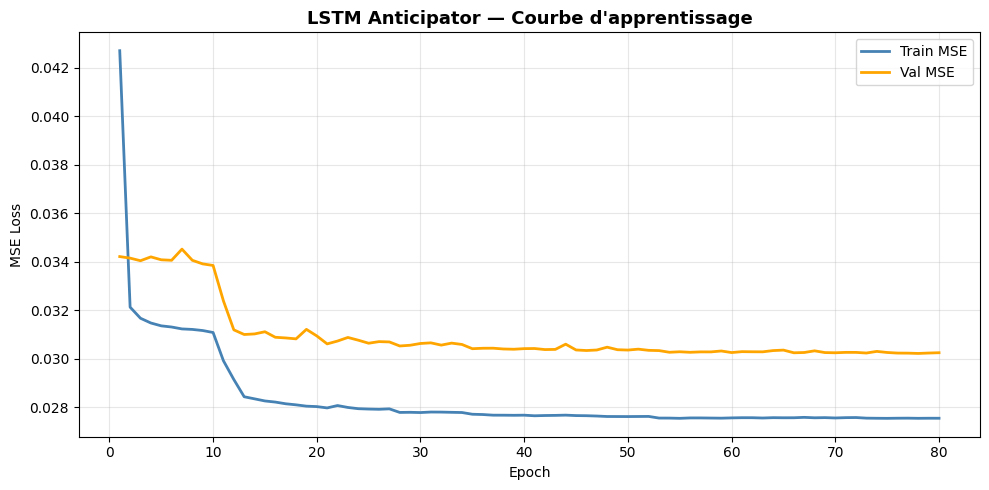

✅ Meilleur Val MSE : 0.030220
💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth


In [ ]:
# ============================================================
# CELL 6 — Training LSTM sur CASIA-B
# ============================================================
from torch.utils.data import random_split

class GaitDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.Y[i]

n_total  = len(X)
n_val    = int(0.2 * n_total)
n_tr     = n_total - n_val
dataset  = GaitDataset(X, Y)

tr_set, val_set = random_split(
    dataset, [n_tr, n_val],
    generator=torch.Generator().manual_seed(SEED))

tr_loader  = DataLoader(tr_set,  batch_size=256,
                        shuffle=True,  num_workers=2)
val_loader_lstm = DataLoader(val_set, batch_size=256,
                        shuffle=False, num_workers=2)

print(f"Train : {n_tr:,} | Val : {n_val:,}")

criterion_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(
    model_lstm.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', patience=5, factor=0.5)

EPOCHS   = 80
best_val = float('inf')
tr_hist  = []   # ← ajouté
val_hist = []   # ← ajouté

print(f"\n🚀 Entraînement LSTM — {EPOCHS} epochs\n")

for epoch in range(1, EPOCHS + 1):
    model_lstm.train()
    tr_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_lstm.zero_grad()
        loss = criterion_lstm(model_lstm(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model_lstm.parameters(), 1.0)
        optimizer_lstm.step()
        tr_loss += loss.item()

    model_lstm.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_lstm:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl_loss += criterion_lstm(
                model_lstm(xb), yb).item()

    tr_loss /= len(tr_loader)
    vl_loss /= len(val_loader_lstm)
    scheduler_lstm.step(vl_loss)

    tr_hist.append(tr_loss)    # ← ajouté
    val_hist.append(vl_loss)   # ← ajouté

    is_best = vl_loss < best_val
    if is_best:
        best_val = vl_loss
        torch.save(model_lstm.state_dict(),
                   '/content/lstm_anticipator_best.pth')

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer_lstm.param_groups[0]['lr']
        print(f"  Ep {epoch:03d} | "
              f"Train: {tr_loss:.5f} | "
              f"Val: {vl_loss:.5f} | "
              f"Best: {best_val:.5f} | "
              f"LR: {lr:.2e} "
              f"{'⭐' if is_best else ''}")

print(f"\n✅ Meilleur Val MSE : {best_val:.6f}")
print(f"💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth")

# ── Courbes MSE ───────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, EPOCHS+1), tr_hist,
        color='steelblue', lw=2, label='Train MSE')
ax.plot(range(1, EPOCHS+1), val_hist,
        color='orange',    lw=2, label='Val MSE')

ax.set_title('LSTM Anticipator — Courbe d\'apprentissage',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/lstm_training.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"✅ Meilleur Val MSE : {best_val:.6f}")
print(f"💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth")


# visualisation

📊 MSE par pas de prédiction :
  t+ 62ms  MSE=0.00073  ███
  t+125ms  MSE=0.00084  ████
  t+187ms  MSE=0.00090  ████
  t+250ms  MSE=0.00133  ██████
  t+312ms  MSE=0.00167  ████████
  t+375ms  MSE=0.00164  ████████
  t+437ms  MSE=0.00245  ████████████
  t+500ms  MSE=0.00250  ████████████


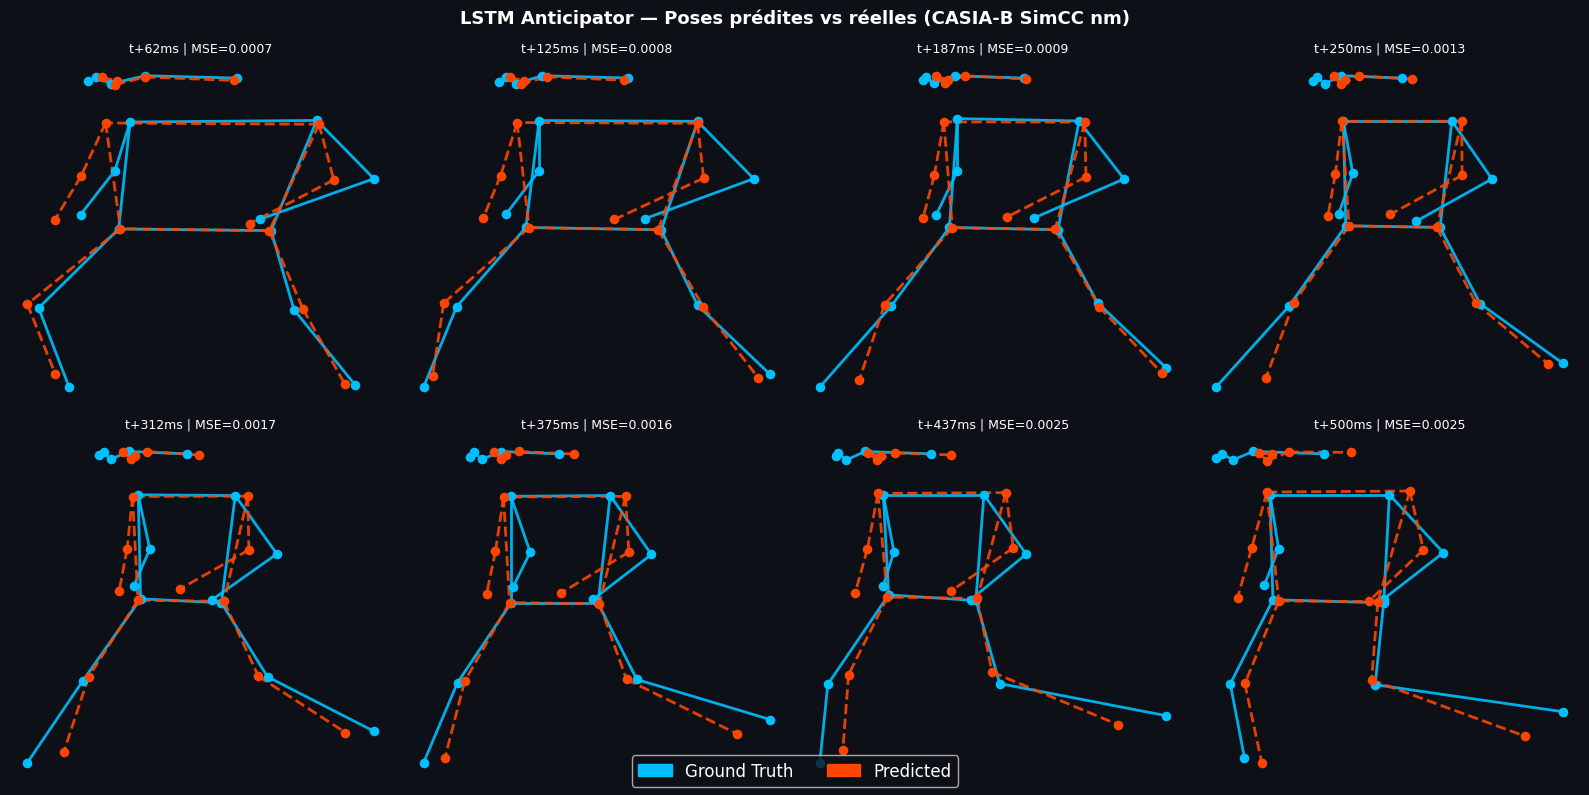

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL — Visualisation poses prédites vs réelles
import matplotlib.patches as mpatches

SKELETON_PAIRS = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

# ── Fix : model → model_lstm ──────────────────────────────────
model_lstm.load_state_dict(
    torch.load('/content/lstm_anticipator_best.pth',
               map_location=DEVICE,
               weights_only=False))
model_lstm.eval()

x_samp = dataset[n_tr][0].unsqueeze(0).to(DEVICE)
y_true = dataset[n_tr][1].numpy()

with torch.no_grad():
    y_pred = model_lstm(x_samp).cpu().numpy()[0]

step_mse = [np.mean((y_pred[s] - y_true[s])**2)
            for s in range(PREDICT_STEPS)]

print("📊 MSE par pas de prédiction :")
for s, mse in enumerate(step_mse):
    ms  = (s + 1) * 1000 // FPS
    bar = '█' * int(mse * 5000)
    print(f"  t+{ms:3d}ms  MSE={mse:.5f}  {bar}")

def flat2kp(arr):
    return arr.reshape(17, 2)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')

for step in range(PREDICT_STEPS):
    ax = axes[step // 4][step % 4]
    ax.set_facecolor('#0d1117')
    ax.invert_yaxis()

    gt = flat2kp(y_true[step])
    pr = flat2kp(y_pred[step])

    for i, j in SKELETON_PAIRS:
        ax.plot([gt[i,0], gt[j,0]],
                [gt[i,1], gt[j,1]],
                color='deepskyblue', lw=2, alpha=0.9)
    ax.scatter(gt[:,0], gt[:,1],
               c='deepskyblue', s=35, zorder=5)

    for i, j in SKELETON_PAIRS:
        ax.plot([pr[i,0], pr[j,0]],
                [pr[i,1], pr[j,1]],
                color='orangered', lw=2, alpha=0.9,
                linestyle='--')
    ax.scatter(pr[:,0], pr[:,1],
               c='orangered', s=35, zorder=5)

    ms = (step + 1) * 1000 // FPS
    ax.set_title(f"t+{ms}ms | MSE={step_mse[step]:.4f}",
                 color='white', fontsize=9)
    ax.axis('off')

handles = [
    mpatches.Patch(color='deepskyblue', label='Ground Truth'),
    mpatches.Patch(color='orangered',   label='Predicted')
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=12, facecolor='#0d1117',
           labelcolor='white')
fig.suptitle(
    "LSTM Anticipator — Poses prédites vs réelles (CASIA-B SimCC nm)",
    color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/lstm_poses.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

from google.colab import files
files.download('/content/lstm_poses.png')

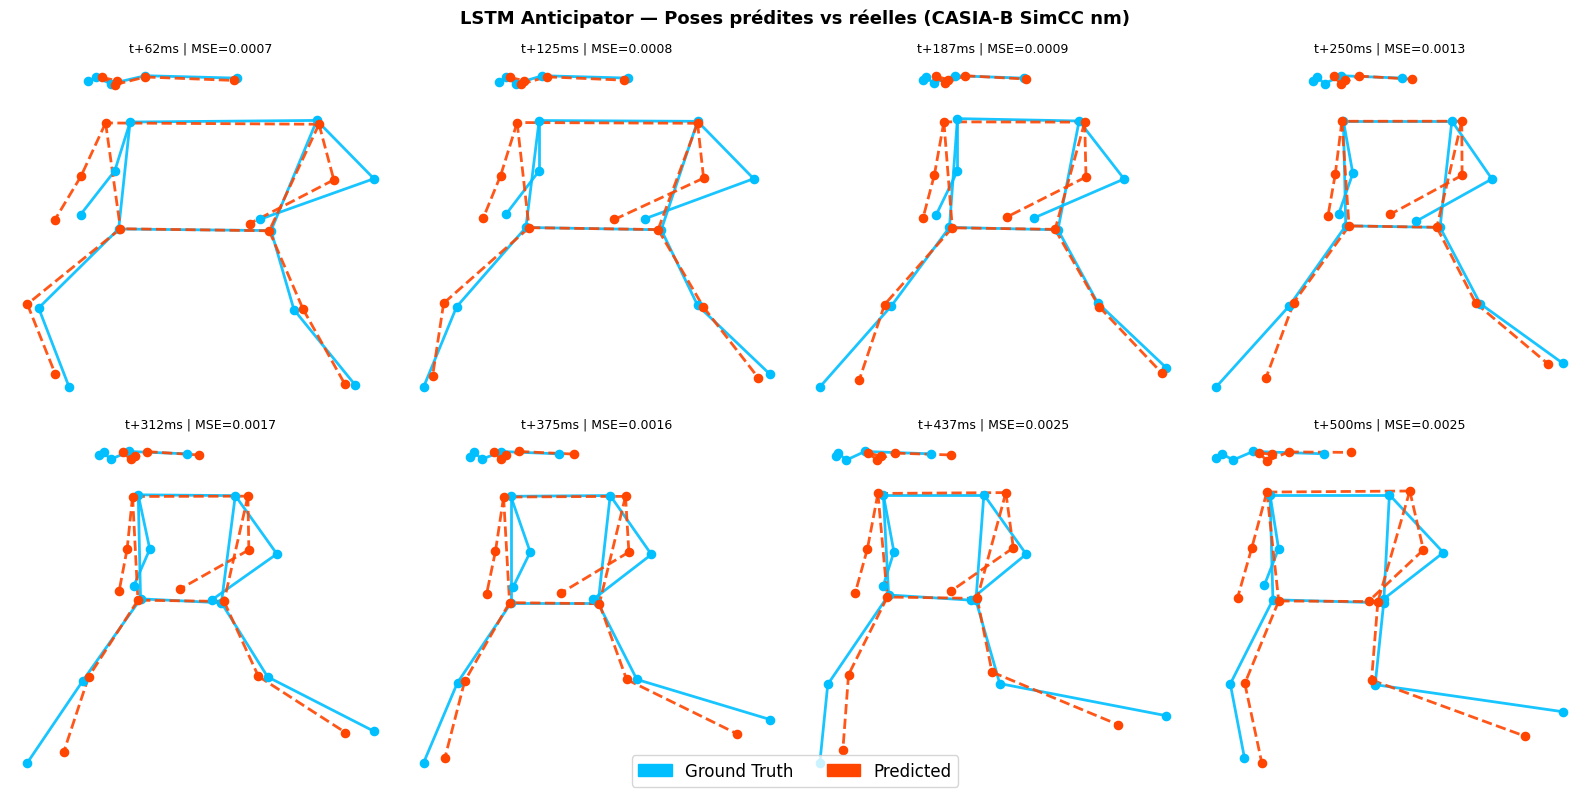

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CELL — Visualisation poses prédites vs réelles
import matplotlib.patches as mpatches

SKELETON_PAIRS = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

model_lstm.load_state_dict(
    torch.load('/content/lstm_anticipator_best.pth',
               map_location=DEVICE,
               weights_only=False))
model_lstm.eval()

x_samp = dataset[n_tr][0].unsqueeze(0).to(DEVICE)
y_true = dataset[n_tr][1].numpy()

with torch.no_grad():
    y_pred = model_lstm(x_samp).cpu().numpy()[0]

step_mse = [np.mean((y_pred[s] - y_true[s])**2)
            for s in range(PREDICT_STEPS)]

def flat2kp(arr):
    return arr.reshape(17, 2)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('white')          # ← white figure background

for step in range(PREDICT_STEPS):
    ax = axes[step // 4][step % 4]
    ax.set_facecolor('white')             # ← white axes background
    ax.invert_yaxis()

    gt = flat2kp(y_true[step])
    pr = flat2kp(y_pred[step])

    for i, j in SKELETON_PAIRS:
        ax.plot([gt[i,0], gt[j,0]],
                [gt[i,1], gt[j,1]],
                color='deepskyblue', lw=2, alpha=0.9)
    ax.scatter(gt[:,0], gt[:,1],
               c='deepskyblue', s=35, zorder=5)

    for i, j in SKELETON_PAIRS:
        ax.plot([pr[i,0], pr[j,0]],
                [pr[i,1], pr[j,1]],
                color='orangered', lw=2, alpha=0.9,
                linestyle='--')
    ax.scatter(pr[:,0], pr[:,1],
               c='orangered', s=35, zorder=5)

    ms = (step + 1) * 1000 // FPS
    ax.set_title(f"t+{ms}ms | MSE={step_mse[step]:.4f}",
                 color='black', fontsize=9)  # ← black title text
    ax.axis('off')

handles = [
    mpatches.Patch(color='deepskyblue', label='Ground Truth'),
    mpatches.Patch(color='orangered',   label='Predicted')
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=12, facecolor='white',              # ← white legend bg
           labelcolor='black')                          # ← black legend text
fig.suptitle(
    "LSTM Anticipator — Poses prédites vs réelles (CASIA-B SimCC nm)",
    color='black', fontsize=13, fontweight='bold')      # ← black title

plt.tight_layout()
plt.savefig('/content/lstm_poses.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')                          # ← white saved bg
plt.show()

from google.colab import files
files.download('/content/lstm_poses.png')

In [ ]:
# ============================================================
# CELL 7 — Download URFD
# ============================================================
urfd_path_raw = kagglehub.dataset_download(
    "mireillejabbour/fall-dataset")
print(f"✅ URFD path: {urfd_path_raw}")

100%|██████████| 8.05G/8.05G [01:36<00:00, 89.8MB/s]

Extracting files...


✅ URFD path: /root/.cache/kagglehub/datasets/mireillejabbour/fall-dataset/versions/2


In [ ]:
# ============================================================
# CELL 8 — Fix MediaPipe
# ============================================================
!pip install mediapipe==0.10.14 -q
print("✅ Installation terminée")
print("⚠️  REDÉMARRE LE KERNEL : Runtime → Restart session")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 29.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
✅ Installation terminée
⚠️  REDÉMARRE LE KERNEL : Runtime → Restart session


In [ ]:
# ============================================================
# CELL 9 — Extraction Keypoints URFD (MediaPipe)
# ============================================================
import os, cv2, numpy as np, pickle
import mediapipe as mp
from pathlib import Path
from tqdm import tqdm

URFD_ROOT = Path(urfd_path_raw)
SAVE_PATH = Path("/content/urfd_keypoints")
SAVE_PATH.mkdir(exist_ok=True)

MP_INDICES = [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9,
              12, 11, 14, 13, 16, 15]

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

MODEL_PATH = "/content/pose_landmarker_heavy.task"
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/"
        "pose_landmarker/pose_landmarker_heavy/float16/"
        "latest/pose_landmarker_heavy.task",
        MODEL_PATH)
    print("✅ Modèle téléchargé")

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    num_poses=1,
    min_pose_detection_confidence=0.1,
    min_pose_presence_confidence=0.1,
    min_tracking_confidence=0.1,
    running_mode=vision.RunningMode.IMAGE
)
pose = vision.PoseLandmarker.create_from_options(options)
print("✅ PoseLandmarker initialisé")

def extract_keypoints_mediapipe(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w     = img_rgb.shape[:2]
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results  = pose.detect(mp_image)
    if (not results.pose_landmarks
            or len(results.pose_landmarks) == 0):
        return None
    lm = results.pose_landmarks[0]
    kp = np.zeros((17, 3), dtype=np.float32)
    for coco_idx, mp_idx in enumerate(MP_INDICES):
        kp[coco_idx, 0] = lm[mp_idx].x * w
        kp[coco_idx, 1] = lm[mp_idx].y * h
        kp[coco_idx, 2] = getattr(
            lm[mp_idx], 'visibility', 1.0)
    return kp

def process_sequence(seq_dir, min_frames=5,
                     min_rate=0.5):
    frames    = sorted(seq_dir.glob("*.png"))
    if len(frames) == 0:
        return None
    keypoints = []
    for fp in frames:
        kp = extract_keypoints_mediapipe(fp)
        if kp is not None:
            keypoints.append(kp)
    det_rate = len(keypoints) / max(len(frames), 1)
    if len(keypoints) < min_frames or det_rate < min_rate:
        return None
    return np.stack(keypoints, axis=0)

def get_actual_dir(seq_dir):
    inner = [d for d in seq_dir.iterdir() if d.is_dir()]
    return inner[0] if len(inner) == 1 else seq_dir

# Falls
fall_root = (URFD_ROOT / "fall zip photo files"
             / "fall zip photo files")
fall_dirs      = sorted([d for d in fall_root.iterdir()
                         if d.is_dir()])
fall_sequences = {}
for seq_dir in tqdm(fall_dirs, desc="Falls"):
    kp = process_sequence(get_actual_dir(seq_dir))
    if kp is not None:
        fall_sequences[seq_dir.name] = kp

# ADLs
adl_root = (URFD_ROOT / "adl zip photo files"
            / "adl zip photo files")
adl_dirs      = sorted([d for d in adl_root.iterdir()
                        if d.is_dir()])
adl_sequences = {}
for seq_dir in tqdm(adl_dirs, desc="ADLs"):
    kp = process_sequence(get_actual_dir(seq_dir))
    if kp is not None:
        adl_sequences[seq_dir.name] = kp

with open(SAVE_PATH / "fall_keypoints.pkl", 'wb') as f:
    pickle.dump(fall_sequences, f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'wb') as f:
    pickle.dump(adl_sequences, f)

print(f"\n✅ Falls : {len(fall_sequences)}")
print(f"✅ ADLs  : {len(adl_sequences)}")

✅ Modèle téléchargé
✅ PoseLandmarker initialisé


Falls:   0%|          | 0/118 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
ADLs: 100%|██████████| 80/80 [26:37<00:00, 19.97s/it]


✅ Falls : 110
✅ ADLs  : 66


In [ ]:
# ============================================================
# CELL 10 — Labellisation URFD
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH  = Path("/content/urfd_keypoints")
PRE_FALL_F = 20
FALL_F     = 15

with open(SAVE_PATH / "fall_keypoints.pkl", 'rb') as f:
    fall_sequences = pickle.load(f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'rb') as f:
    adl_sequences = pickle.load(f)

def label_fall_sequence(T):
    labels        = np.zeros(T, dtype=np.int64)
    fall_start    = max(0, T - FALL_F)
    prefall_start = max(0, T - FALL_F - PRE_FALL_F)
    labels[prefall_start:fall_start] = 1
    labels[fall_start:]              = 2
    return labels

labeled_data = []

for name, kp in fall_sequences.items():
    T = kp.shape[0]
    labeled_data.append({
        'keypoints': kp,
        'labels':    label_fall_sequence(T),
        'name':      name,
        'is_fall':   True
    })

for name, kp in adl_sequences.items():
    T = kp.shape[0]
    labeled_data.append({
        'keypoints': kp,
        'labels':    np.zeros(T, dtype=np.int64),
        'name':      name,
        'is_fall':   False
    })

all_labels = np.concatenate(
    [d['labels'] for d in labeled_data])
counts = Counter(all_labels.tolist())
total  = len(all_labels)

print(f"📊 Labels :")
print(f"  STABLE   : {counts[0]} ({100*counts[0]/total:.1f}%)")
print(f"  PRE-FALL : {counts[1]} ({100*counts[1]/total:.1f}%)")
print(f"  FALL     : {counts[2]} ({100*counts[2]/total:.1f}%)")

with open(SAVE_PATH / "labeled_data.pkl", 'wb') as f:
    pickle.dump(labeled_data, f)
print(f"✅ Saved: labeled_data.pkl")

📊 Labels :
  STABLE   : 16848 (81.4%)
  PRE-FALL : 2200 (10.6%)
  FALL     : 1650 (8.0%)
✅ Saved: labeled_data.pkl


In [ ]:
# ============================================================
# CELL 11 — Preprocessing URFD → X_urfd.npy (1:1:1)
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH   = Path("/content/urfd_keypoints")
WINDOW_SIZE = 30
STRIDE      = 1

with open(SAVE_PATH / "labeled_data.pkl", 'rb') as f:
    labeled_data = pickle.load(f)

def extract_features_urfd(kp_seq):
    xy         = kp_seq[:, :, :2].copy()
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(
        xy[:, 0, :] - hip_center,
        axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    rel        = rel / torso_h[:, np.newaxis, :]
    return rel.reshape(len(kp_seq), -1).astype(np.float32)

X_all = {0: [], 1: [], 2: []}

for sample in labeled_data:
    kp   = sample['keypoints']
    labs = sample['labels']
    T    = len(kp)
    if T < WINDOW_SIZE + 1:
        continue
    feats = extract_features_urfd(kp)
    for start in range(0, T - WINDOW_SIZE):
        end       = start + WINDOW_SIZE
        win_label = int(labs[end - 1])
        X_all[win_label].append(feats[start:end])

n_min = min(len(X_all[0]),
            len(X_all[1]),
            len(X_all[2]))

np.random.seed(42)
X_balanced, Y_balanced = [], []
for cls in [0, 1, 2]:
    arr = np.array(X_all[cls])
    if len(arr) > n_min:
        idx = np.random.choice(len(arr), n_min,
                               replace=False)
        arr = arr[idx]
    X_balanced.append(arr)
    Y_balanced.append(
        np.full(len(arr), cls, dtype=np.int64))

X = np.concatenate(X_balanced, axis=0)
Y = np.concatenate(Y_balanced, axis=0)

shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
Y = Y[shuffle_idx]

counts = Counter(Y.tolist())
print(f"✅ Dataset équilibré :")
print(f"   X shape  : {X.shape}")
print(f"   STABLE   : {counts[0]}")
print(f"   PRE-FALL : {counts[1]}")
print(f"   FALL     : {counts[2]}")

np.save(SAVE_PATH / "X_urfd.npy", X.astype(np.float32))
np.save(SAVE_PATH / "Y_urfd.npy", Y)
print(f"✅ Saved: X_urfd.npy, Y_urfd.npy")

✅ Dataset équilibré :
   X shape  : (4608, 30, 34)
   STABLE   : 1536
   PRE-FALL : 1536
   FALL     : 1536
✅ Saved: X_urfd.npy, Y_urfd.npy


In [ ]:
# ============================================================
# CELL 12 — Architecture DGNNClassifier (Baseline: DGNN only)
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

N_JOINTS = 17

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

def build_adjacency():
    A_src  = torch.zeros(N_JOINTS, N_JOINTS)
    A_tgt  = torch.zeros(N_JOINTS, N_JOINTS)
    A_self = torch.eye(N_JOINTS)
    for (i, j) in COCO_EDGES:
        A_src[i, j] = 1.0
        A_tgt[j, i] = 1.0
    def normalize(A):
        D = A.sum(dim=1, keepdim=True).clamp(min=1)
        return A / D
    return normalize(A_src), normalize(A_tgt), A_self


class DGNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.W_src  = nn.Linear(in_channels, out_channels, bias=False)
        self.W_tgt  = nn.Linear(in_channels, out_channels, bias=False)
        self.W_self = nn.Linear(in_channels, out_channels, bias=False)
        self.bn  = nn.BatchNorm1d(out_channels)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x, A_src, A_tgt, A_self):
        B, N, C = x.shape
        h_src  = torch.bmm(A_src.unsqueeze(0).expand(B,-1,-1), x)
        h_tgt  = torch.bmm(A_tgt.unsqueeze(0).expand(B,-1,-1), x)
        h_self = torch.bmm(A_self.unsqueeze(0).expand(B,-1,-1), x)
        out = (self.W_src(h_src) + self.W_tgt(h_tgt) + self.W_self(h_self))
        out = self.bn(out.view(B*N, -1)).view(B, N, -1)
        return self.act(out)


class DGNNClassifier(nn.Module):
    def __init__(self, T=30, n_classes=3, hidden=64):
        super().__init__()
        self.T          = T
        self.input_proj = nn.Linear(2, hidden)
        self.dgnn1      = DGNNLayer(hidden,   hidden)
        self.dgnn2      = DGNNLayer(hidden,   hidden*2)
        self.dgnn3      = DGNNLayer(hidden*2, hidden*2)

        # After 3 DGNN layers: (B, T, N_JOINTS * hidden*2)
        # Global average pool over T and N → flat vector
        dgnn_out = N_JOINTS * hidden * 2   # 17 * 128 = 2176

        self.classifier = nn.Sequential(
            nn.Linear(dgnn_out, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),      nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )
        A_src, A_tgt, A_self = build_adjacency()
        self.register_buffer('A_src',  A_src)
        self.register_buffer('A_tgt',  A_tgt)
        self.register_buffer('A_self', A_self)

    def forward(self, x):
        B, T, _ = x.shape
        xg = x.view(B, T, N_JOINTS, 2)
        frame_features = []
        for t in range(T):
            xt = xg[:, t, :, :]
            xt = self.input_proj(xt)
            xt = self.dgnn1(xt, self.A_src, self.A_tgt, self.A_self)
            xt = self.dgnn2(xt, self.A_src, self.A_tgt, self.A_self)
            xt = self.dgnn3(xt, self.A_src, self.A_tgt, self.A_self)
            xt = xt.view(B, -1)           # (B, N_JOINTS * hidden*2)
            frame_features.append(xt)

        # Stack → (B, T, dgnn_out), then mean over time
        seq = torch.stack(frame_features, dim=1)  # (B, T, 2176)
        out = seq[:, -3:, :].mean(dim=1)                      # (B, 2176) — no LSTM, no GRU
        return self.classifier(out)


model_dgnn = DGNNClassifier(T=30, n_classes=3, hidden=64).to(DEVICE)

n_params = sum(p.numel() for p in model_dgnn.parameters() if p.requires_grad)
print(f"✅ DGNNClassifier (no LSTM) : {n_params:,} paramètres")
dummy = torch.zeros(4, 30, 34).to(DEVICE)
print(f"   Test : {dummy.shape} → {model_dgnn(dummy).shape} ✓")

✅ DGNNClassifier (no LSTM) : 677,443 paramètres
   Test : torch.Size([4, 30, 34]) → torch.Size([4, 3]) ✓


In [ ]:
# ============================================================
# CELL 13 — No Weight Transfer (DGNN-only baseline)
# ============================================================
# Since the DGNNClassifier no longer has a GRU/LSTM,
# there are no recurrent weights to transfer from LSTMAnticipator.
# The DGNN layers are initialized from scratch.

print("ℹ️  Baseline mode: no weight transfer")
print("   DGNNClassifier has no recurrent module → skipping transfer")
print("   All weights initialized from scratch")
print(f"\n📋 Stratégie Fine-Tuning (single phase):")
print(f"   Phase unique : ep 1-200 | tout entraîné | lr=1e-3")

ℹ️  Baseline mode: no weight transfer
   DGNNClassifier has no recurrent module → skipping transfer
   All weights initialized from scratch

📋 Stratégie Fine-Tuning (single phase):
   Phase unique : ep 1-200 | tout entraîné | lr=1e-3


In [ ]:
# ============================================================
# CELL 14 — Fine-Tuning Baseline DGNN sur URFD (single phase)
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import f1_score, classification_report
from collections import Counter
from pathlib import Path

SAVE_PATH = Path("/content/urfd_keypoints")
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED      = 42

X_urfd = np.load(SAVE_PATH / "X_urfd.npy")
Y_urfd = np.load(SAVE_PATH / "Y_urfd.npy")
print(f"X_urfd : {X_urfd.shape} | Y_urfd : {Y_urfd.shape}")

class URFDDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.Y[i]

dataset = URFDDataset(X_urfd, Y_urfd)
n_total = len(dataset)
n_val   = int(0.2 * n_total)
n_tr    = n_total - n_val

tr_set, val_set = random_split(
    dataset, [n_tr, n_val],
    generator=torch.Generator().manual_seed(SEED))

tr_loader  = DataLoader(tr_set,  batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

print(f"Train : {n_tr:,} | Val : {n_val:,}")

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

criterion = FocalLoss(gamma=2.0)

# ── Single phase: everything trained from scratch ─────────────
EPOCHS  = 200
best_f1 = 0.0
history = []

optimizer = torch.optim.AdamW(
    model_dgnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=200, eta_min=1e-6)

print(f"\n🚀 Training Baseline DGNN — {EPOCHS} epochs")
print(f"   Single phase | lr=1e-3 | no weight transfer\n")

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────
    model_dgnn.train()
    total_loss    = 0.0
    train_correct = 0
    train_total   = 0

    for xb, yb in tr_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model_dgnn(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_dgnn.parameters(), 1.0)
        optimizer.step()
        total_loss    += loss.item()
        train_correct += (logits.argmax(dim=1) == yb).sum().item()
        train_total   += len(yb)
    scheduler.step()

    train_loss = total_loss / len(tr_loader)
    train_acc  = train_correct / train_total

    # ── Validation ────────────────────────────────────────────
    model_dgnn.eval()
    val_loss_total  = 0.0
    all_preds, all_true = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model_dgnn(xb)
            val_loss_total += criterion(logits, yb).item()
            p = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(p)
            all_true.extend(yb.cpu().numpy())

    val_loss  = val_loss_total / len(val_loader)
    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    val_acc   = np.mean(all_preds == all_true)
    val_f1    = f1_score(all_true, all_preds,
                         average='macro', zero_division=0)
    f1_all    = f1_score(all_true, all_preds,
                         average=None, zero_division=0)
    f1_pre    = f1_all[1] if len(f1_all) > 1 else 0.0
    f1_fall   = f1_all[2] if len(f1_all) > 2 else 0.0

    is_best = val_f1 > best_f1
    if is_best:
        best_f1 = val_f1
        torch.save({
            'epoch':       epoch,
            'val_f1':      val_f1,
            'val_acc':     val_acc,
            'model_state': model_dgnn.state_dict()
        }, '/content/dgnn_baseline_best.pth')

    history.append({
        'epoch':      epoch,
        'train_loss': train_loss,
        'val_loss':   val_loss,
        'train_acc':  train_acc,
        'val_acc':    val_acc,
        'val_f1':     val_f1,
        'f1_pre':     f1_pre,
        'f1_fall':    f1_fall
    })

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"Ep {epoch:03d} | "
              f"TrLoss: {train_loss:.4f} | "
              f"ValLoss: {val_loss:.4f} | "
              f"TrAcc: {train_acc:.3f} | "
              f"ValAcc: {val_acc:.3f} | "
              f"F1: {val_f1:.3f} | "
              f"LR: {lr:.1e} "
              f"{'⭐' if is_best else ''}")

# ── Final report ──────────────────────────────────────────────
print("\n" + "="*55)
ckpt = torch.load('/content/dgnn_baseline_best.pth',
                  map_location=DEVICE, weights_only=False)
model_dgnn.load_state_dict(ckpt['model_state'])
print(f"✅ Best : epoch {ckpt['epoch']} | F1={ckpt['val_f1']:.4f}")

model_dgnn.eval()
all_logits, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        all_logits.append(model_dgnn(xb.to(DEVICE)).cpu())
        all_true.extend(yb.tolist())

all_logits = torch.cat(all_logits)
all_probs  = torch.softmax(all_logits, dim=1).numpy()
all_true   = np.array(all_true)

print("\n  Threshold sweep :")
best_thresh, best_fall_f1 = 0.3, 0.0
for thresh in np.arange(0.10, 0.60, 0.05):
    preds_t = all_logits.argmax(dim=1).numpy().copy()
    preds_t[all_probs[:, 2] > thresh] = 2
    f1_t    = f1_score(all_true, preds_t,
                       average=None, zero_division=0)
    f1_mac  = f1_score(all_true, preds_t,
                       average='macro', zero_division=0)
    f1_fall = f1_t[2] if len(f1_t) > 2 else 0
    print(f"    thresh={thresh:.2f} | "
          f"F1_fall={f1_fall:.3f} | "
          f"F1_macro={f1_mac:.3f}")
    if f1_fall > best_fall_f1:
        best_fall_f1 = f1_fall
        best_thresh  = thresh

print(f"\n✅ Best threshold : {best_thresh:.2f} → "
      f"F1_fall={best_fall_f1:.3f}")

preds_final = all_logits.argmax(dim=1).numpy().copy()
preds_final[all_probs[:, 2] > best_thresh] = 2

print("\n📊 RAPPORT FINAL (Baseline — DGNN only):")
print("="*55)
print(classification_report(
    all_true, preds_final,
    target_names=['STABLE', 'PRE-FALL', 'FALL']))

X_urfd : (4608, 30, 34) | Y_urfd : (4608,)
Train : 3,687 | Val : 921

🚀 Training Baseline DGNN — 200 epochs
   Single phase | lr=1e-3 | no weight transfer

Ep 001 | TrLoss: 0.4291 | ValLoss: 0.3756 | TrAcc: 0.506 | ValAcc: 0.548 | F1: 0.542 | LR: 1.0e-03 ⭐
Ep 010 | TrLoss: 0.2719 | ValLoss: 0.2775 | TrAcc: 0.654 | ValAcc: 0.655 | F1: 0.626 | LR: 9.9e-04 
Ep 020 | TrLoss: 0.1987 | ValLoss: 0.2540 | TrAcc: 0.723 | ValAcc: 0.655 | F1: 0.655 | LR: 9.8e-04 
Ep 030 | TrLoss: 0.1662 | ValLoss: 0.2257 | TrAcc: 0.751 | ValAcc: 0.718 | F1: 0.697 | LR: 9.5e-04 
Ep 040 | TrLoss: 0.1259 | ValLoss: 0.2351 | TrAcc: 0.806 | ValAcc: 0.754 | F1: 0.746 | LR: 9.0e-04 
Ep 050 | TrLoss: 0.1049 | ValLoss: 0.2203 | TrAcc: 0.835 | ValAcc: 0.789 | F1: 0.785 | LR: 8.5e-04 ⭐
Ep 060 | TrLoss: 0.0822 | ValLoss: 0.2251 | TrAcc: 0.871 | ValAcc: 0.796 | F1: 0.788 | LR: 7.9e-04 
Ep 070 | TrLoss: 0.0663 | ValLoss: 0.2422 | TrAcc: 0.904 | ValAcc: 0.813 | F1: 0.811 | LR: 7.3e-04 
Ep 080 | TrLoss: 0.0495 | ValLoss: 0.2187 

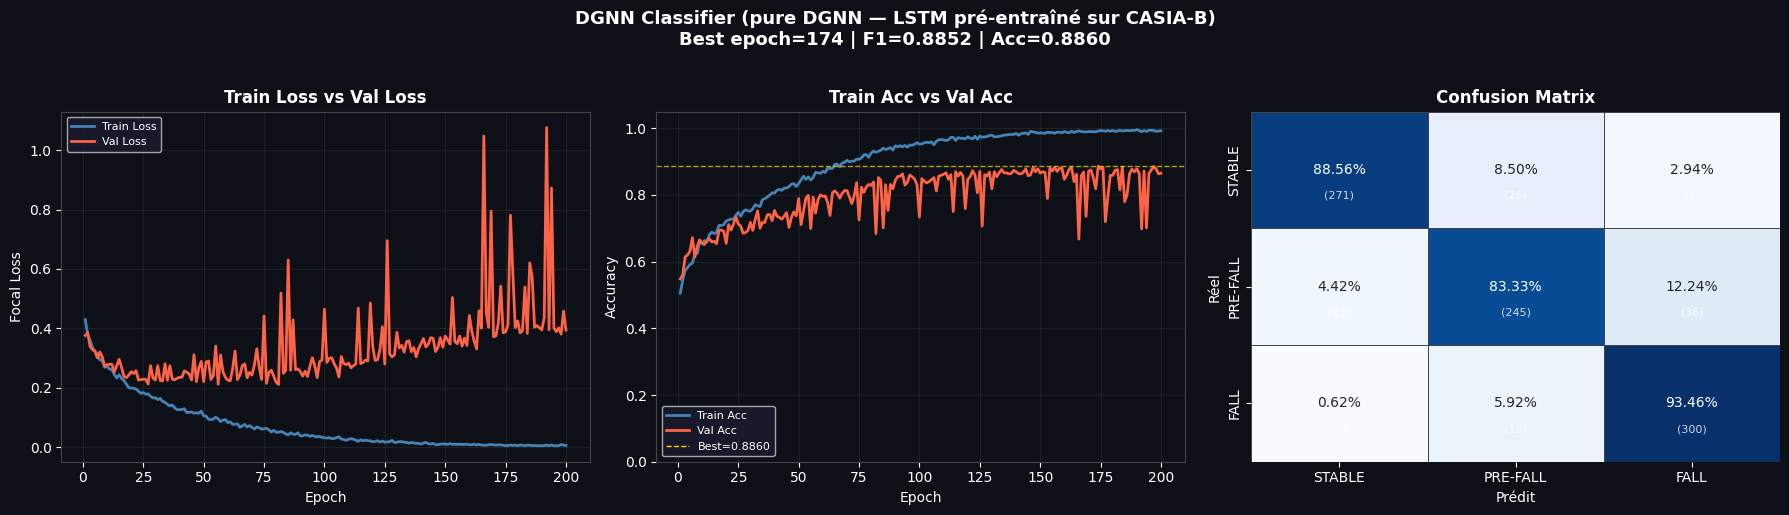


📊 RÉSULTATS FINAUX :
  Best epoch  : 174
  F1 macro    : 0.8852
  Accuracy    : 0.8860
  STABLE      : F1=0.9155
  PRE-FALL    : F1=0.8390
  FALL        : F1=0.9009

📊 Confusion Matrix :
                   STABLE   PRE-FALL       FALL
  STABLE              271         26          9
  PRE-FALL             13        245         36
  FALL                  2         19        300


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 15 — Loss + Accuracy + Confusion Matrix
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
import torch

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASS_NAMES = ['STABLE', 'PRE-FALL', 'FALL']

epochs_     = [h['epoch']      for h in history]
train_loss_ = [h['train_loss'] for h in history]
val_loss_   = [h['val_loss']   for h in history]
train_acc_  = [h['train_acc']  for h in history]
val_acc_    = [h['val_acc']    for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

# ── Graphe 1 : Train Loss vs Val Loss ────────────────────────
axes[0].plot(epochs_, train_loss_,
             color='steelblue', lw=2,
             label='Train Loss')
axes[0].plot(epochs_, val_loss_,
             color='tomato', lw=2,
             label='Val Loss')
axes[0].set_title('Train Loss vs Val Loss',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].grid(alpha=0.15, color='gray')
axes[0].legend(handles=[
    plt.Line2D([0],[0], color='steelblue',
               lw=2, label='Train Loss'),
    plt.Line2D([0],[0], color='tomato',
               lw=2, label='Val Loss')],
    fontsize=8,
    facecolor='#1a1a2e',
    labelcolor='white')

# ── Graphe 2 : Train Acc vs Val Acc ──────────────────────────
axes[1].plot(epochs_, train_acc_,
             color='steelblue', lw=2,
             label='Train Accuracy')
axes[1].plot(epochs_, val_acc_,
             color='tomato', lw=2,
             label='Val Accuracy')
axes[1].axhline(y=ckpt['val_acc'],
                color='gold', ls='--',
                alpha=0.7, lw=1,
                label=f'Best={ckpt["val_acc"]:.4f}')
axes[1].set_title('Train Acc vs Val Acc',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.15, color='gray')
axes[1].legend(handles=[
    plt.Line2D([0],[0], color='steelblue',
               lw=2, label='Train Acc'),
    plt.Line2D([0],[0], color='tomato',
               lw=2, label='Val Acc'),
    plt.Line2D([0],[0], color='gold',
               lw=1, ls='--',
               label=f'Best={ckpt["val_acc"]:.4f}')],
    fontsize=8,
    facecolor='#1a1a2e',
    labelcolor='white')

# ── Graphe 3 : Confusion Matrix ───────────────────────────────
model_dgnn.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        p = model_dgnn(xb.to(DEVICE)).argmax(
            dim=1).cpu().numpy()
        all_preds.extend(p)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(
    axis=1, keepdims=True)

sns.heatmap(cm_norm,
            annot=True, fmt='.2%',
            cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[2],
            linewidths=0.5,
            linecolor='#444444',
            cbar=False)

for i in range(3):
    for j in range(3):
        axes[2].text(
            j + 0.5, i + 0.72,
            f'({cm[i,j]})',
            ha='center', va='center',
            color='white', fontsize=8,
            alpha=0.8)

axes[2].set_title('Confusion Matrix',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Prédit')
axes[2].set_ylabel('Réel')
axes[2].tick_params(colors='white')

# ── Titre global ──────────────────────────────────────────────
plt.suptitle(
    f'DGNN Classifier (pure DGNN — LSTM pré-entraîné sur CASIA-B)\n'
    f'Best epoch={ckpt["epoch"]} | '
    f'F1={ckpt["val_f1"]:.4f} | '
    f'Acc={ckpt["val_acc"]:.4f}',
    color='white', fontsize=13,
    fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('/content/dgnn_results.png',
            dpi=200, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

f1c = f1_score(all_true, all_preds,
               average=None, zero_division=0)
mac = f1_score(all_true, all_preds,
               average='macro', zero_division=0)

print(f"\n📊 RÉSULTATS FINAUX :")
print(f"{'='*50}")
print(f"  Best epoch  : {ckpt['epoch']}")
print(f"  F1 macro    : {mac:.4f}")
print(f"  Accuracy    : {ckpt['val_acc']:.4f}")
print(f"{'='*50}")
print(f"  STABLE      : F1={f1c[0]:.4f}")
print(f"  PRE-FALL    : F1={f1c[1]:.4f}")
print(f"  FALL        : F1={f1c[2]:.4f}")

print(f"\n📊 Confusion Matrix :")
print(f"  {'':12} {'STABLE':>10} "
      f"{'PRE-FALL':>10} {'FALL':>10}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:12} {cm[i,0]:>10} "
          f"{cm[i,1]:>10} {cm[i,2]:>10}")

from google.colab import files
files.download('/content/dgnn_results.png')